In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import random
%matplotlib inline

random.seed(42)
torch.manual_seed(42)
print("PyTorch version:", torch.__version__)

PyTorch version: 2.7.1+cu128


## 2.1 Create a simple CNN
### 4-layer CNN with shortcut connections

In [ ]:
class MyCNN(nn.Module):
    def __init__(self):
        super(MyCNN, self).__init__()
        # Let's assume that the input image is of size 32x32 -- input tensor is of size (batch_size, 3, 32, 32)
        #TODO: Create a minimalist CNN with each base block being the conv-batchnorm-relu-conv-batchnorm-relu combo. Have a shortcut from the input of the base block to the output.
        #TODO: Have a maxpool layer after each base block. Make it halve the spatial dimensions. 
        #TODO: After 3 base blocks, the size of feature maps should be 4x4. Now, flatten this feature map -- it should becomes a batched vector instead of a batched feature map
        #TODO: Use a fully connected layer to turn this into logits for image classification (let's say we have 10 image categories)
    
    def forward(self, x: torch.tensor):
        #TODO: Your logic
        return logits


model = MyCNN()
print(f"Number of parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")

Number of parameters: 307946


## 2.2 Create Datasets

In [ ]:
# Create random images and labels to simulate training and test data. Dataset size=128
train_images = torch.randn(_, _, _, _) # TODO: fill the blank here and below
train_labels = torch.randint(0, _, (_ ,))

test_images = torch.randn(_, _, _, _)
test_labels = torch.randint(0, _, (_ ,))

# Data normalization
train_images = (train_images - 0.5) / 0.5
test_images = (test_images - 0.5) / 0.5

# Create datasets
train_dataset = TensorDataset(train_images, train_labels)
test_dataset = TensorDataset(test_images, test_labels)

# Create dataloaders with batch size 32
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Training set size: {len(train_dataset)} Samples")
print(f"Test set size: {len(test_dataset)} Samples")

Training set size: 128 Samples
Test set size: 128 Samples


## 2.3 Training and Evaluation

Epoch [1/100], Iter [1], Train Acc: 87.50%
Epoch [1/100], Iter [2], Train Acc: 175.00%
Epoch [1/100], Iter [3], Train Acc: 259.38%
Epoch [1/100], Iter [4], Train Acc: 346.88%
Epoch [1/100], Test Acc: 8.59%
Epoch [2/100], Iter [1], Train Acc: 87.50%
Epoch [2/100], Iter [2], Train Acc: 171.88%
Epoch [2/100], Iter [3], Train Acc: 262.50%
Epoch [2/100], Iter [4], Train Acc: 350.00%
Epoch [2/100], Test Acc: 8.59%
Epoch [3/100], Iter [1], Train Acc: 81.25%
Epoch [3/100], Iter [2], Train Acc: 168.75%
Epoch [3/100], Iter [3], Train Acc: 259.38%
Epoch [3/100], Iter [4], Train Acc: 350.00%
Epoch [3/100], Test Acc: 8.59%
Epoch [4/100], Iter [1], Train Acc: 87.50%
Epoch [4/100], Iter [2], Train Acc: 181.25%
Epoch [4/100], Iter [3], Train Acc: 268.75%
Epoch [4/100], Iter [4], Train Acc: 356.25%
Epoch [4/100], Test Acc: 8.59%
Epoch [5/100], Iter [1], Train Acc: 90.62%
Epoch [5/100], Iter [2], Train Acc: 175.00%
Epoch [5/100], Iter [3], Train Acc: 259.38%
Epoch [5/100], Iter [4], Train Acc: 353.12%
E

ValueError: x and y must have same first dimension, but have shapes (100,) and (0,)

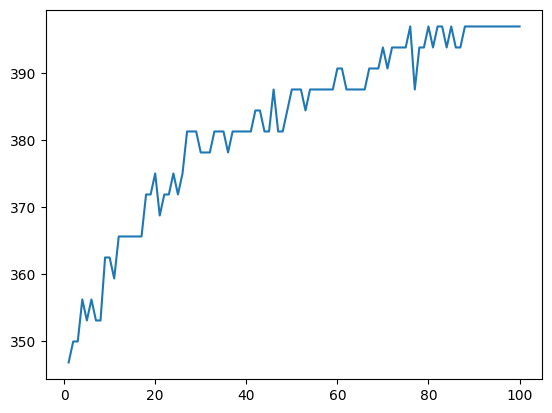

In [ ]:
# TODO: Complete this function that evaluates a model on all test data
@torch.no_grad() # function with this decorator will not create any computational graph; save memory
def evaluate(model, loader):
    # TODO: model to eval mode
    correct = 0
    total = 0
    for images, labels in loader:
        outputs = model(images)
        _, pred = torch.max(outputs, _)
        total += labels.size(_)
        correct += (pred == labels).sum().item()
    return 100 * correct / total


# TODO: loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-6)
num_epochs = 100

train_acc_list = []
test_acc_list = []

# TODO: Complete the training loop
for epoch in range(num_epochs):
    # TODO: model to train mode
    correct, total = 0, 0
    for iter_no, (images, labels) in enumerate(train_loader):
        # TODO: Empty stored gradients
        # TODO: forward pass + loss computation
        # TODO: backprop
        # TODO: model update
        # Compute training loss
        print(f"Epoch [{epoch+1}/{num_epochs}], Iter [{iter_no+1}], Train Acc: {____:.2f}%")

    train_acc_list.append(correct/total*100)
    test_acc = evaluate(model, test_loader)
    test_acc_list.append(test_acc)
    print(f"Epoch [{epoch+1}/{num_epochs}], Test Acc: {test_acc:.2f}%")


# TODO: Plot training curve
plt.figure()
plt.plot(range(1, num_epochs+1), train_acc_list, label='Train Accuracy')
plt.plot(range(1, num_epochs+1), test_acc_list, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.title('Training Curve')
plt.show()

In [ ]:
()